生成された系列
S1: 1000110111010100001001011001111
S2: 1001111100011011101010000100101
S3: 1011101010000100101100111110001
S4: 1110101000010010110011111000110
S5: 1111000110111010100001001011001

最大相関行列
[[31 31 31 31 31]
 [31 31 31 31 31]
 [31 31 31 31 31]
 [31 31 31 31 31]
 [31 31 31 31 31]]

最大相関になるシフト
[[ 0  7 26 24  3]
 [24  0 19 17 27]
 [ 5 12  0 29  8]
 [ 7 14  2  0 10]
 [28  4 23 21  0]]


C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 35079 (\N{CJK UNIFIED IDEOGRAPH-8907}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:103: UserWarning: Glyph 26368 (\N{CJK UNIFIED 

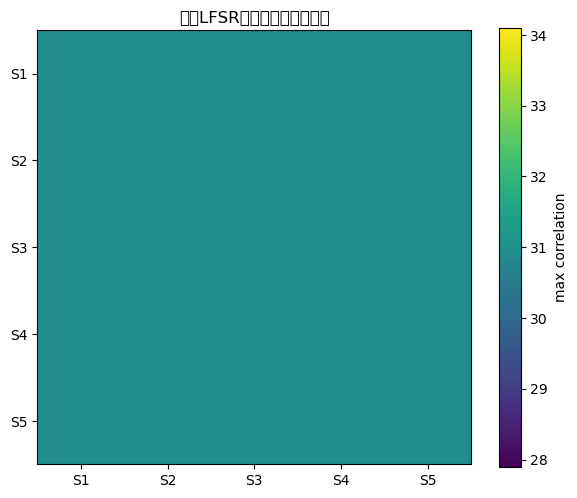


同期補足テスト
対象系列: S3
本当のシフト: 7
推定シフト: 7
最大相関: 31


C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 35036 (\N{CJK UNIFIED IDEOGRAPH-88DC}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 36275 (\N{CJK UNIFIED IDEOGRAPH-8DB3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:133: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDE

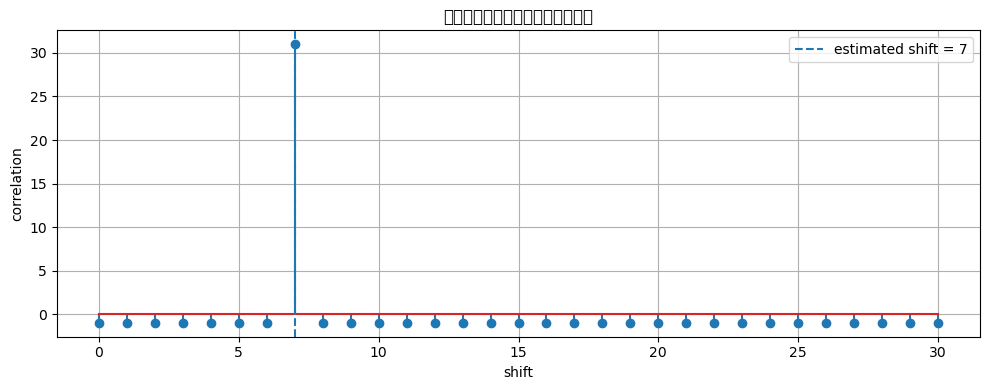


Gold系列の例
G1: 0001001011001111100011011101010
G2: 0100001001011001111100011011101
G3: 1110101000010010110011111000110
G4: 0011111000110111010100001001011
G5: 1101010000100101100111110001101


C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 21015 (\N{CJK UNIFIED IDEOGRAPH-5217}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_8108\3322576502.py:168: UserWarning: Glyph 30456 (\N{CJK UNIFIED 

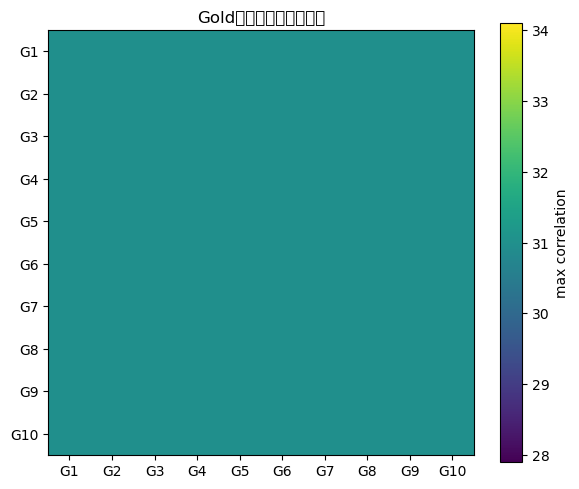

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# LFSR
# -----------------------------

def lfsr_sequence(seed, taps, n_bits):
    state = seed[:]
    seq = []

    for _ in range(n_bits):
        out = state[-1]
        seq.append(out)

        feedback = 0
        for t in taps:
            feedback ^= state[t]

        state = [feedback] + state[:-1]

    return np.array(seq)

def bit_to_pm1(bits):
    return np.where(bits == 0, 1, -1)

def cyclic_corr(a, b):
    """全位相の巡回相関"""
    x = bit_to_pm1(a)
    y = bit_to_pm1(b)

    corr = []
    for shift in range(len(a)):
        corr.append(np.sum(x * np.roll(y, -shift)))
    return np.array(corr)

def max_correlation(a, b):
    corr = cyclic_corr(a, b)
    return np.max(corr), np.argmax(corr)

# -----------------------------
# 複数系列を生成
# -----------------------------

m = 5
period = 2**m - 1

# 例: x^5 + x^2 + 1
taps = [2, 4]

seeds = [
    [1, 0, 0, 0, 1],
    [1, 1, 0, 0, 1],
    [1, 1, 1, 0, 1],
    [1, 0, 1, 1, 1],
    [0, 1, 1, 1, 1],
]

sequences = []

for seed in seeds:
    seq = lfsr_sequence(seed, taps, period)
    sequences.append(seq)

# -----------------------------
# 系列表示
# -----------------------------

print("生成された系列")
for i, seq in enumerate(sequences):
    print(f"S{i+1}:", "".join(map(str, seq)))

# -----------------------------
# 相互相関行列
# -----------------------------

n = len(sequences)
corr_matrix = np.zeros((n, n), dtype=int)
shift_matrix = np.zeros((n, n), dtype=int)

for i in range(n):
    for j in range(n):
        value, shift = max_correlation(sequences[i], sequences[j])
        corr_matrix[i, j] = value
        shift_matrix[i, j] = shift

print("\n最大相関行列")
print(corr_matrix)

print("\n最大相関になるシフト")
print(shift_matrix)

# -----------------------------
# ヒートマップ表示
# -----------------------------

plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar(label="max correlation")
plt.xticks(range(n), [f"S{i+1}" for i in range(n)])
plt.yticks(range(n), [f"S{i+1}" for i in range(n)])
plt.title("複数LFSR系列の最大相関行列")
plt.tight_layout()
plt.show()

# -----------------------------
# 同期補足の例
# -----------------------------

target_id = 2
true_shift = 7

reference = sequences[target_id]
received = np.roll(reference, true_shift)

corr = cyclic_corr(reference, received)
estimated_shift = np.argmax(corr)

print("\n同期補足テスト")
print("対象系列:", f"S{target_id+1}")
print("本当のシフト:", true_shift)
print("推定シフト:", estimated_shift)
print("最大相関:", corr[estimated_shift])

plt.figure(figsize=(10, 4))
plt.stem(range(period), corr)
plt.axvline(estimated_shift, linestyle="--", label=f"estimated shift = {estimated_shift}")
plt.title("同期補足：位相シフトごとの相関")
plt.xlabel("shift")
plt.ylabel("correlation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Gold系列の生成
# -----------------------------

seq_a = sequences[0]
seq_b = sequences[1]

gold_sequences = []

for shift in range(period):
    gold = seq_a ^ np.roll(seq_b, shift)
    gold_sequences.append(gold)

print("\nGold系列の例")
for i in range(5):
    print(f"G{i+1}:", "".join(map(str, gold_sequences[i])))

# Gold系列の相関行列
g_num = 10
gold_corr_matrix = np.zeros((g_num, g_num), dtype=int)

for i in range(g_num):
    for j in range(g_num):
        value, shift = max_correlation(gold_sequences[i], gold_sequences[j])
        gold_corr_matrix[i, j] = value

plt.figure(figsize=(6, 5))
plt.imshow(gold_corr_matrix)
plt.colorbar(label="max correlation")
plt.xticks(range(g_num), [f"G{i+1}" for i in range(g_num)])
plt.yticks(range(g_num), [f"G{i+1}" for i in range(g_num)])
plt.title("Gold系列の最大相関行列")
plt.tight_layout()
plt.show()